In [3]:
# import statements
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.datasets import fetch_openml

In [4]:
X, y = fetch_openml('mnist_784', version=1, return_X_y=True) # getting data from online
print('X shape:', X.shape, 'y shape:', y.shape)

X shape: (70000, 784) y shape: (70000,)


In [5]:
X = X.values # this converts X from a pandas dataframe to a numpy array

digits = {j:[] for j in range(10)}
for j in range(len(y)): # takes data assigns it into a dictionary
    digits[int(y[j])].append(X[j].reshape(28,28))
digits = {j:np.stack(digits[j]) for j in range(10)} # stack everything to be one numpy array
for j in range(10):
    print('Shape of data with label', j, ':', digits[j].shape )

Shape of data with label 0 : (6903, 28, 28)
Shape of data with label 1 : (7877, 28, 28)
Shape of data with label 2 : (6990, 28, 28)
Shape of data with label 3 : (7141, 28, 28)
Shape of data with label 4 : (6824, 28, 28)
Shape of data with label 5 : (6313, 28, 28)
Shape of data with label 6 : (6876, 28, 28)
Shape of data with label 7 : (7293, 28, 28)
Shape of data with label 8 : (6825, 28, 28)
Shape of data with label 9 : (6958, 28, 28)


In [6]:
data = []
for i in range(10):
    flattened_images = digits[i][:100].reshape(100,-1)
    data.append(flattened_images)
    
data = np.vstack(data)
data = data.astype('float32') / 255.0

In [7]:
X49 = np.vstack([digits[4][:500], digits[9][:500]])
y49 = np.hstack([-np.ones(500, dtype=np.int8), np.ones(500, dtype=np.int8)])

X49 = X49.reshape(1000, 784).astype("float") / 255.0

rng = np.random.default_rng(0)
perm = rng.permutation(len(y49))
X49, y49 = X49[perm], y49[perm]

In [8]:
def F(w, X, y):
    z = y * (X @ w)
    return np.mean(np.log(1 + np.exp(-z)))

def grad_F(w, X, y):
    z = y * (X @ w)
    s = 1 / (1 + np.exp(z))
    return -(X.T @ (y * s)) / len(y)


In [9]:
def gd_momentum(X, y, mu=0.01, beta=0.9, iters=100):
    features = X.shape[1]
    w_prev = np.zeros(features)
    w = np.zeros(features)

    hist = []

    for k in range(iters):
        g = grad_F(w, X, y)
        momentum = beta * (w - w_prev)

        w_next = w - mu * g + momentum

        w_prev = w
        w = w_next

        hist.append(F(w, X, y))

    return w, hist

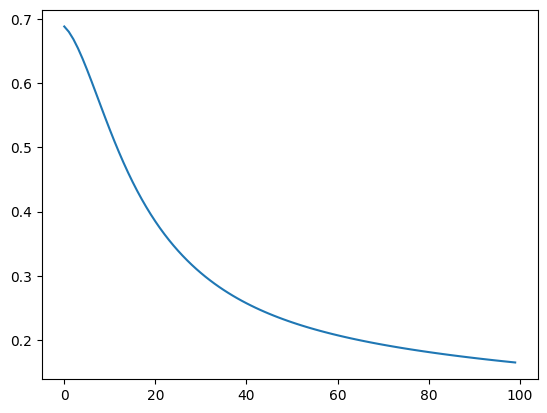

In [10]:
w_momentum, hist_momentum = gd_momentum(X49, y49, mu=0.01, beta=0.9, iters=100)
plt.plot(hist_momentum)

In [11]:
def gd_nesterov(X, y, mu=0.01, beta=0.9, iters=100):
    features = X.shape[1]
    w_prev = np.zeros(features)
    w = np.zeros(features)

    hist = []

    for k in range(iters):
        y_k = w + beta * (w - w_prev)

        g = grad_F(y_k, X, y) 

        w_next = y_k - mu * g

        w_prev = w
        w = w_next

        hist.append(F(w, X, y))

    return w, hist


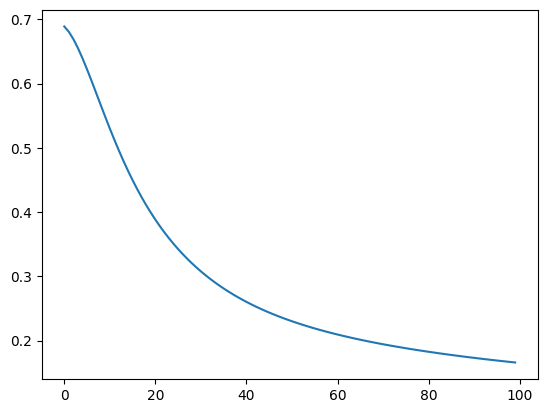

In [12]:
w_nes, hist_nes = gd_nesterov(X49, y49, mu=0.01, beta=0.9, iters=100)
plt.plot(hist_nes)
plt.show()


In [17]:
def optimal(n):
    A = np.diag(np.arange(1, n+1))
    b = np.ones(n)
    return A, b

A20, b20 = optimal(20)
x_star_20 = np.linalg.solve(A20, b20)

A100, b100 = optimal(100)
x_star_100 = np.linalg.solve(A100, b100)

x_star_20, x_star_100

(array([1.        , 0.5       , 0.33333333, 0.25      , 0.2       ,
        0.16666667, 0.14285714, 0.125     , 0.11111111, 0.1       ,
        0.09090909, 0.08333333, 0.07692308, 0.07142857, 0.06666667,
        0.0625    , 0.05882353, 0.05555556, 0.05263158, 0.05      ]),
 array([1.        , 0.5       , 0.33333333, 0.25      , 0.2       ,
        0.16666667, 0.14285714, 0.125     , 0.11111111, 0.1       ,
        0.09090909, 0.08333333, 0.07692308, 0.07142857, 0.06666667,
        0.0625    , 0.05882353, 0.05555556, 0.05263158, 0.05      ,
        0.04761905, 0.04545455, 0.04347826, 0.04166667, 0.04      ,
        0.03846154, 0.03703704, 0.03571429, 0.03448276, 0.03333333,
        0.03225806, 0.03125   , 0.03030303, 0.02941176, 0.02857143,
        0.02777778, 0.02702703, 0.02631579, 0.02564103, 0.025     ,
        0.02439024, 0.02380952, 0.02325581, 0.02272727, 0.02222222,
        0.02173913, 0.0212766 , 0.02083333, 0.02040816, 0.02      ,
        0.01960784, 0.01923077, 0.01886792, 0.

In [20]:
def f(x, A, b):
    return 0.5 * x.T @ (A @ x) - b.T @ x

def gradient(x, A, b):
    return A @ x - b

def GD(A, b, x_star, iters=1000):
    n = len(b)
    mu = 1.0 / n

    x = np.zeros(n)
    f_hist = []
    dist_hist = []

    f_star = f(x_star, A, b)

    for t in range(iters):
        grad = gradient(x, A, b)
        x = x - mu * grad

        f_hist.append(f(x, A, b) - f_star)
        dist_hist.append(np.linalg.norm(x - x_star))

    return x, f_hist, dist_hist

In [23]:
A20, b20 = optimal(20)
x_star_20 = 1 / np.arange(1, 21)
x_20, f_hist_20, dist_hist_20 = GD(A20, b20, x_star_20)

A100, b100 = optimal(100)
x_star_100 = 1 / np.arange(1, 101)
x_100, f_hist_100, dist_hist_100 = GD(A100, b100, x_star_100)

In [24]:
def heavy_ball(A, b, x_star, iters=1000, beta=0.9):
    n = len(b)
    mu = 1.0 / n

    x_prev = np.zeros(n)
    x = np.zeros(n)

    f_hist = []
    dist_hist = []

    f_star = f(x_star, A, b)

    for t in range(iters):
        grad = A @ x - b

        # Heavy Ball update
        x_new = x - mu * grad + beta * (x - x_prev)

        x_prev = x
        x = x_new

        f_hist.append(f(x, A, b) - f_star)
        dist_hist.append(np.linalg.norm(x - x_star))

    return x, f_hist, dist_hist


In [25]:
A20, b20 = optimal(20)
x_star_20 = 1 / np.arange(1, 21)
x_hb_20, f_hb_20, dist_hb_20 = heavy_ball(A20, b20, x_star_20)

A100, b100 = optimal(100)
x_star_100 = 1 / np.arange(1, 101)
x_hb_100, f_hb_100, dist_hb_100 = heavy_ball(A100, b100, x_star_100)

In [26]:
def nesterov(A, b, x_star, iters=1000, beta=0.9):
    n = len(b)
    mu = 1.0 / n

    x_prev = np.zeros(n)
    x = np.zeros(n)

    f_hist = []
    dist_hist = []

    f_star = f(x_star, A, b)

    for t in range(iters):
        y = x + beta * (x - x_prev)

        grad_y = A @ y - b

        x_new = y - mu * grad_y

        x_prev = x
        x = x_new

        f_hist.append(f(x, A, b) - f_star)
        dist_hist.append(np.linalg.norm(x - x_star))

    return x, f_hist, dist_hist


In [27]:
A20, b20 = optimal(20)
x_star_20 = 1 / np.arange(1, 21)
x_nes_20, f_nes_20, dist_nes_20 = nesterov(A20, b20, x_star_20)

A100, b100 = optimal(100)
x_star_100 = 1 / np.arange(1, 101)
x_nes_100, f_nes_100, dist_nes_100 = nesterov(A100, b100, x_star_100)


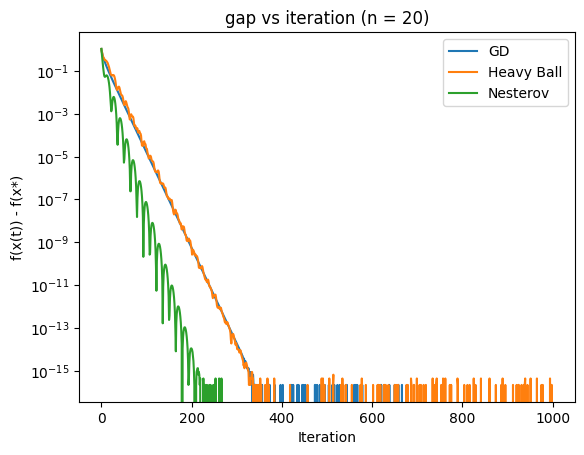

In [32]:
T = len(f_hist_20)
iters = range(T)

plt.semilogy(iters, f_hist_20,   label='GD')
plt.semilogy(iters, f_hb_20,     label='Heavy Ball')
plt.semilogy(iters, f_nes_20,    label='Nesterov')
plt.xlabel('Iteration')
plt.ylabel('f(x(t)) - f(x*)')
plt.title('gap vs iteration (n = 20)')
plt.legend()
plt.show()


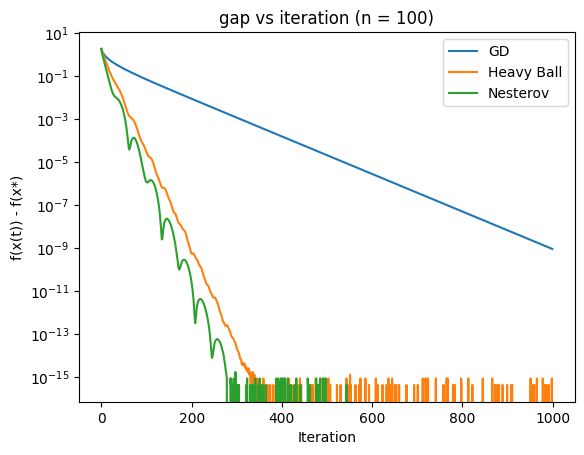

In [33]:
T = len(f_hist_100)
iters = range(T)

plt.semilogy(iters, f_hist_100,   label='GD')
plt.semilogy(iters, f_hb_100,     label='Heavy Ball')
plt.semilogy(iters, f_nes_100,    label='Nesterov')
plt.xlabel('Iteration')
plt.ylabel('f(x(t)) - f(x*)')
plt.title('gap vs iteration (n = 100)')
plt.legend()
plt.show()


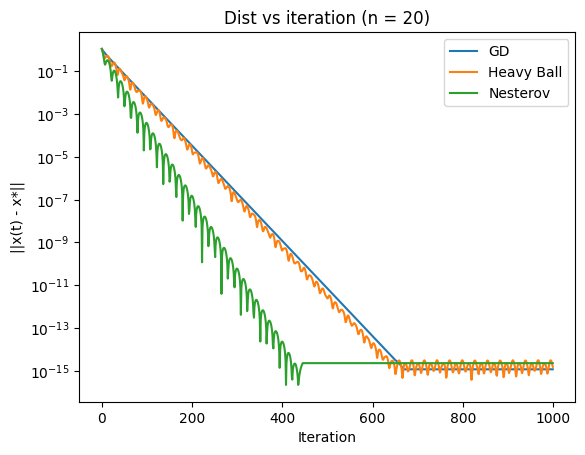

In [35]:
T = len(dist_hist_20)
iters = range(T)

plt.semilogy(iters, dist_hist_20,   label='GD')
plt.semilogy(iters, dist_hb_20,     label='Heavy Ball')
plt.semilogy(iters, dist_nes_20,    label='Nesterov')
plt.xlabel('Iteration')
plt.ylabel('||x(t) - x*||')
plt.title('Dist vs iteration (n = 20)')
plt.legend()
plt.show()


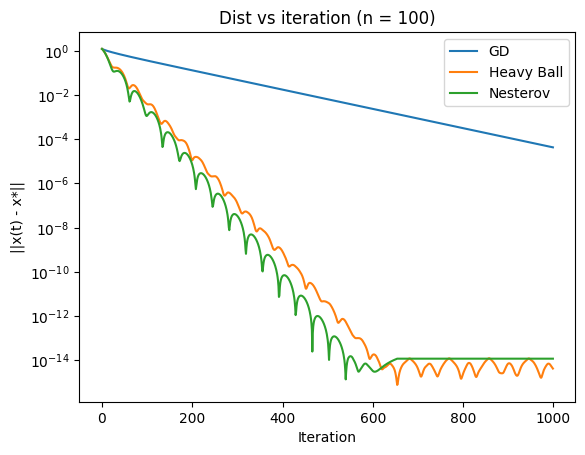

In [36]:
T = len(dist_hist_100)
iters = range(T)

plt.semilogy(iters, dist_hist_100,   label='GD')
plt.semilogy(iters, dist_hb_100,     label='Heavy Ball')
plt.semilogy(iters, dist_nes_100,    label='Nesterov')
plt.xlabel('Iteration')
plt.ylabel('||x(t) - x*||')
plt.title('Dist vs iteration (n = 100)')
plt.legend()
plt.show()


Gradient Descent shows linear convergence, just like predicted. Heavy Ball is slightly faster at some points, but it also oscillates more and doesn’t consistently beat the regular GD. Nesterov acceleration is the fastest of the three, reducing the error fastest in every plot. When n gets larger, GD slows down because the problem becomes less well conditioned, but Nesterov still performs very well.